In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm

In [13]:
optimize_mask = [1,0,1,0]
initial_guess = [2,3,4,5]

optimized_params = [10,20]

initial_optimize_guess = [param for param, opt in zip(initial_guess, optimize_mask) if opt]
fixed_params = [param for param, opt in zip(initial_guess, optimize_mask) if not opt]


def combine_params(optimized_params, fixed_params, optimize_mask):
    """
    Helper function to combine optimized and fixed parameters based on the optimize_mask.

    Parameters:
    optimized_params: jnp.ndarray - The parameters that are being optimized.
    fixed_params: jnp.ndarray - The parameters that are fixed.
    optimize_mask: jnp.ndarray - A boolean mask indicating which parameters to optimize.

    Returns:
    jnp.ndarray - A combined array of parameters.
    """
    optimize_mask = jnp.asarray(optimize_mask)
    optimized_params = jnp.asarray(optimized_params)
    fixed_params = jnp.asarray(fixed_params)


    # Determine the total length based on the optimize_mask
    full_params_length = optimize_mask.shape[0]

    # Create an array to hold the combined parameters
    full_params = jnp.zeros(full_params_length, dtype=optimized_params.dtype)

    # Create indices for filling the optimized and fixed params
    opt_indices = jnp.arange(len(optimized_params))
    fixed_indices = jnp.arange(len(fixed_params))

    # Fill the full_params array based on the optimize_mask
    full_params = jnp.where(
        optimize_mask,
        optimized_params[jnp.minimum(opt_indices, len(optimized_params) - 1)],  # Use optimized params
        fixed_params[jnp.minimum(fixed_indices, len(fixed_params) - 1)]       # Use fixed params
    )

    return full_params


# Combine optimized and fixed parameters
full_params = combine_params(optimized_params, fixed_params, optimize_mask)

print(initial_optimize_guess)
print(fixed_params)
print(full_params)

ValueError: Incompatible shapes for broadcasting: shapes=[(4,), (2,), (2,)]

In [3]:
def plot_img_logscale(proj_density_mat):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                    

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat.T, norm=colors.LogNorm(vmin=proj_density_mat.min(), vmax=proj_density_mat.max()), origin='lower')
    plt.colorbar(label='Color Scale')
    plt.show()

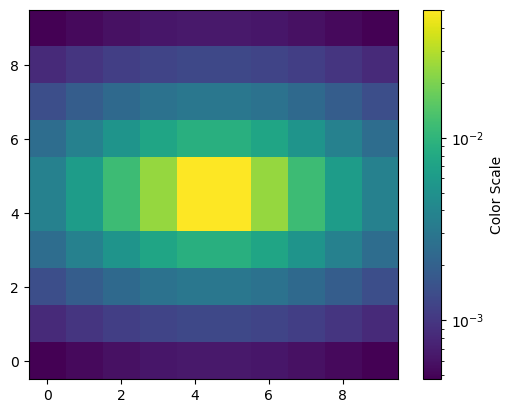

In [4]:
import JAX_Deprojection.surface_brightness as sb
import JAX_Deprojection.density_distribution as den

s = 1. 
e = 0.
p = 0.5
q = 0.6
a = 2.
b = 4.
rho0 = 0.001
size = 10
extent = 1
i = 0.
phi = 0.
theta = 0.

sb1= sb.Surface_brightness()
sb1.generate(size,extent, e, p, q, rho0, s, a, b, i, phi, theta)
plot_img_logscale(sb1.data)

In [5]:
bounds = [(0.01),(1.)]
initial_params = [e,1.,q,rho0,s,a,b,i,phi,theta]
optimize_mask = [0,1,0,0,0,0,0,0,0,0]

pred_den = sb1.deproject(bounds, initial_params, optimize_mask)

TracerBoolConversionError: Attempted boolean conversion of traced array with shape int32[]..
The error occurred while tracing the function ssd_score_for_minimize at /home/mj/Desktop/Astro_Master/JAX_deprojection/JAX_Deprojection/utils.py:64 for jit. This concrete value was not available in Python because it depends on the values of the arguments args[5][0], args[5][1], args[5][2], args[5][3], args[5][4], args[5][5], args[5][6], args[5][7], args[5][8], and args[5][9].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerBoolConversionError

1